In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [12]:
cols_to_keep = [
    'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties',
    'Day_of_Week', '1st_Road_Class', '1st_Road_Number', 'Road_Type',
    'Speed_limit', 'Junction_Detail', 'Junction_Control',
    'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions',
    'Special_Conditions_at_Site', 'Carriageway_Hazards', 'Urban_or_Rural_Area'
]

df = pd.read_csv("AccidentsBig.csv",
                  usecols=cols_to_keep,
                  on_bad_lines='skip',
                  low_memory=False)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Severity unique:", df['Accident_Severity'].unique())
print(df.head())

Shape: (270537, 16)
Columns: ['Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Day_of_Week', '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit', 'Junction_Detail', 'Junction_Control', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Special_Conditions_at_Site', 'Carriageway_Hazards', 'Urban_or_Rural_Area']
Severity unique: [ 2.  3.  1. nan]
   Accident_Severity  Number_of_Vehicles  Number_of_Casualties  Day_of_Week  \
0                2.0                 1.0                   1.0          3.0   
1                3.0                 1.0                   1.0          4.0   
2                3.0                 2.0                   1.0          5.0   
3                3.0                 1.0                   1.0          6.0   
4                3.0                 1.0                   1.0          2.0   

   1st_Road_Class  1st_Road_Number  Road_Type  Speed_limit  Junction_Detail  \
0             3.0           3218.0        6.0     

In [13]:
# Check nulls
print("Null values:\n", df.isnull().sum())

# Drop nulls
df = df.dropna()

# Drop duplicates
df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)
print("Severity distribution:\n", df['Accident_Severity'].value_counts())

Null values:
 Accident_Severity             210539
Number_of_Vehicles            210539
Number_of_Casualties          210539
Day_of_Week                   210539
1st_Road_Class                210539
1st_Road_Number               210539
Road_Type                     210539
Speed_limit                   210539
Junction_Detail               210539
Junction_Control              210539
Light_Conditions              210539
Weather_Conditions            210539
Road_Surface_Conditions       210539
Special_Conditions_at_Site    210539
Carriageway_Hazards           210539
Urban_or_Rural_Area           210539
dtype: int64
Shape after cleaning: (45494, 16)
Severity distribution:
 Accident_Severity
3.0    38518
2.0     6348
1.0      628
Name: count, dtype: int64


In [14]:
df['Accident_Severity'] = df['Accident_Severity'].map({
    1: 'Fatal',
    2: 'Serious',
    3: 'Slight'
})

df = df.dropna(subset=['Accident_Severity'])

print("After mapping:\n", df['Accident_Severity'].value_counts())
print("Shape:", df.shape)

After mapping:
 Accident_Severity
Slight     38518
Serious     6348
Fatal        628
Name: count, dtype: int64
Shape: (45494, 16)


In [15]:
# Weekend flag
df['is_weekend'] = df['Day_of_Week'].apply(lambda x: 1 if x in [1, 7] else 0)

# High speed flag
df['high_speed'] = df['Speed_limit'].apply(lambda x: 1 if x >= 60 else 0)

# Multi vehicle flag
df['multi_vehicle'] = df['Number_of_Vehicles'].apply(lambda x: 1 if x > 1 else 0)

# High casualty flag
df['high_casualty'] = df['Number_of_Casualties'].apply(lambda x: 1 if x > 2 else 0)

# Bad light flag
df['bad_light'] = df['Light_Conditions'].apply(lambda x: 1 if x != 1 else 0)

# Bad weather flag
df['bad_weather'] = df['Weather_Conditions'].apply(lambda x: 1 if x != 1 else 0)

# Bad road surface flag
df['bad_surface'] = df['Road_Surface_Conditions'].apply(lambda x: 1 if x != 1 else 0)

print("New features added!")
print("Shape:", df.shape)
print(df.head())

New features added!
Shape: (45494, 23)
  Accident_Severity  Number_of_Vehicles  Number_of_Casualties  Day_of_Week  \
0           Serious                 1.0                   1.0          3.0   
1            Slight                 1.0                   1.0          4.0   
2            Slight                 2.0                   1.0          5.0   
3            Slight                 1.0                   1.0          6.0   
4            Slight                 1.0                   1.0          2.0   

   1st_Road_Class  1st_Road_Number  Road_Type  Speed_limit  Junction_Detail  \
0             3.0           3218.0        6.0         30.0              0.0   
1             4.0            450.0        3.0         30.0              6.0   
2             5.0              0.0        6.0         30.0              0.0   
3             3.0           3220.0        6.0         30.0              0.0   
4             6.0              0.0        6.0         30.0              0.0   

   Junction_Contr

In [16]:
print("Before business logic:", df.shape)

# Speed limit: 10 to 100
df = df[(df['Speed_limit'] >= 10) & (df['Speed_limit'] <= 100)]

# Vehicles: 1 to 20
df = df[(df['Number_of_Vehicles'] >= 1) & (df['Number_of_Vehicles'] <= 20)]

# Casualties: 0 to 50
df = df[(df['Number_of_Casualties'] >= 0) & (df['Number_of_Casualties'] <= 50)]

print("After business logic:", df.shape)

Before business logic: (45494, 23)
After business logic: (45494, 23)


In [17]:
print("Before std removal:", df.shape)

numerical_cols = ['Speed_limit', 'Number_of_Vehicles', 'Number_of_Casualties']

for col in numerical_cols:
    mean = df[col].mean()
    std  = df[col].std()
    lower = mean - 3 * std
    upper = mean + 3 * std
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("After std removal:", df.shape)

Before std removal: (45494, 23)
After std removal: (43869, 23)


In [18]:
le_target = LabelEncoder()
df['Accident_Severity'] = le_target.fit_transform(df['Accident_Severity'])

print("Classes:", le_target.classes_)
print("Target distribution:\n", pd.Series(df['Accident_Severity']).value_counts())

Classes: ['Fatal' 'Serious' 'Slight']
Target distribution:
 Accident_Severity
2    37327
1     5994
0      548
Name: count, dtype: int64


In [19]:
X = df.drop(columns=['Accident_Severity'])
y = df['Accident_Severity']

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (43869, 22)
y distribution:
 Accident_Severity
2    37327
1     5994
0      548
Name: count, dtype: int64


In [20]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {2: 37327, 1: 5994, 0: 548}
After SMOTE: {1: 37327, 2: 37327, 0: 37327}


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (89584, 22)
Testing size: (22397, 22)


In [22]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [23]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf, X_train, y_train, cv=kfold, scoring='accuracy')

print("K-Fold Scores:", cv_scores)
print("Mean Accuracy:", round(cv_scores.mean()*100, 2), "%")
print("Std Dev:", round(cv_scores.std()*100, 2), "%")

K-Fold Scores: [0.90355528 0.90171346 0.9057878  0.90528548 0.90098236]
Mean Accuracy: 90.35 %
Std Dev: 0.19 %


In [24]:
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [25]:
y_pred = best_rf.predict(X_test)

print("Test Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Test Accuracy: 90.55 %

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.96      0.97      0.97      7501
     Serious       0.93      0.79      0.85      7344
      Slight       0.84      0.95      0.89      7552

    accuracy                           0.91     22397
   macro avg       0.91      0.90      0.90     22397
weighted avg       0.91      0.91      0.90     22397



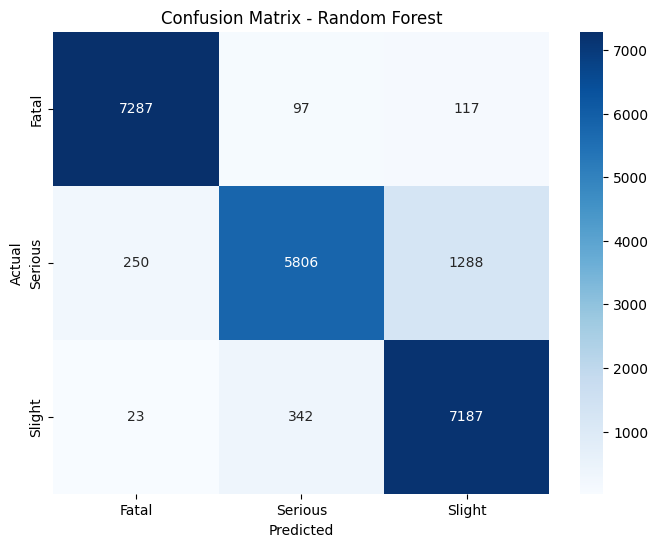

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Top 10 Most Dangerous Roads:
     1st_Road_Number  accident_count is_blackspot
0                0.0            6843   BLACK SPOT
6                6.0             885   BLACK SPOT
1                1.0             525   BLACK SPOT
45              56.0             496   BLACK SPOT
4                4.0             448   BLACK SPOT
315            406.0             397         Safe
46              57.0             385         Safe
48              59.0             352         Safe
33              40.0             346         Safe
47              58.0             325         Safe


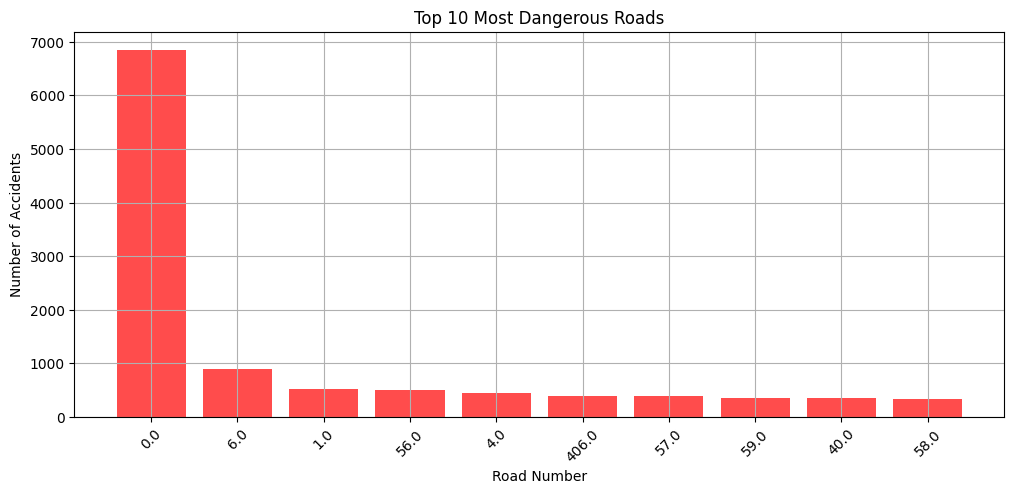

In [27]:
blackspots = df.groupby('1st_Road_Number').size().reset_index(name='accident_count')
blackspots = blackspots.sort_values('accident_count', ascending=False)
blackspots['is_blackspot'] = blackspots['accident_count'].apply(
    lambda x: 'BLACK SPOT' if x >= 400 else 'Safe'
)

print("Top 10 Most Dangerous Roads:")
print(blackspots.head(10))

plt.figure(figsize=(12, 5))
plt.bar(blackspots.head(10)['1st_Road_Number'].astype(str),
        blackspots.head(10)['accident_count'],
        color='red', alpha=0.7)
plt.title("Top 10 Most Dangerous Roads")
plt.xlabel("Road Number")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [28]:
print(f"{'Actual':<15} {'Predicted':<15} {'Result':<10}")
print("-" * 40)

for actual, predicted in zip(y_test[:10], y_pred[:10]):
    actual_name    = le_target.classes_[actual]
    predicted_name = le_target.classes_[predicted]
    match = "Correct" if actual == predicted else "Wrong"
    print(f"{actual_name:<15} {predicted_name:<15} {match:<10}")

Actual          Predicted       Result    
----------------------------------------
Fatal           Fatal           Correct   
Slight          Slight          Correct   
Serious         Slight          Wrong     
Serious         Serious         Correct   
Fatal           Fatal           Correct   
Fatal           Fatal           Correct   
Serious         Slight          Wrong     
Fatal           Fatal           Correct   
Slight          Slight          Correct   
Slight          Slight          Correct   


In [29]:
with open("rf_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("blackspots.pkl", "wb") as f:
    pickle.dump(blackspots, f)

with open("le_target.pkl", "wb") as f:
    pickle.dump(le_target, f)

print("All files saved successfully!")
print("Files: rf_model.pkl, scaler.pkl, blackspots.pkl, le_target.pkl")

All files saved successfully!
Files: rf_model.pkl, scaler.pkl, blackspots.pkl, le_target.pkl


In [30]:
model_info = {
    "features": list(X.columns),
    "target_classes": list(le_target.classes_),
    "model_accuracy": round(accuracy_score(y_test, y_pred)*100, 2),
    "total_accidents": int(len(df)),
    "blackspot_threshold": 400,
    "blackspot_roads": blackspots[
        blackspots['is_blackspot'] == 'BLACK SPOT'
    ]['1st_Road_Number'].tolist()
}

with open("model_info.json", "w") as f:
    json.dump(model_info, f, indent=4)

print("Model info saved!")
print(json.dumps(model_info, indent=4))

Model info saved!
{
    "features": [
        "Number_of_Vehicles",
        "Number_of_Casualties",
        "Day_of_Week",
        "1st_Road_Class",
        "1st_Road_Number",
        "Road_Type",
        "Speed_limit",
        "Junction_Detail",
        "Junction_Control",
        "Light_Conditions",
        "Weather_Conditions",
        "Road_Surface_Conditions",
        "Special_Conditions_at_Site",
        "Carriageway_Hazards",
        "Urban_or_Rural_Area",
        "is_weekend",
        "high_speed",
        "multi_vehicle",
        "high_casualty",
        "bad_light",
        "bad_weather",
        "bad_surface"
    ],
    "target_classes": [
        "Fatal",
        "Serious",
        "Slight"
    ],
    "model_accuracy": 90.55,
    "total_accidents": 43869,
    "blackspot_threshold": 400,
    "blackspot_roads": [
        0.0,
        6.0,
        1.0,
        56.0,
        4.0
    ]
}
